<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/practice/Student_TimeSeries_Forecasting_Example_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 비주식 시계열 예측 과제

학번 : 2526527002
이름 : 박성원

## 주제: 월별 CO2 농도 예측

- 데이터 종류: 환경/기후 시계열
- 데이터 출처: NOAA Global Monitoring Laboratory
- 데이터 수집 방식: URL 직접 로드
- 예측 모델: Holt-Winters(Exponential Smoothing)

공개 시계열 데이터를 사용하며, Colab에서 바로 실행 할 수 있도록 구성했습니다.
공식 기관이 제공하는 공개 데이터라 신뢰성이 높고 `pandas.read_csv()`로 직접 불러올 수 있어 실습 환경 구성이 쉽습니다. 또한 장기 추세와 계절성이 뚜렷해서 시계열 예측 개념 설명에 적합합니다.

In [ ]:
# 필요한 패키지가 없으면 자동으로 설치합니다.
import sys
import subprocess
import importlib.util

def ensure_package(package_name):
    if importlib.util.find_spec(package_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

ensure_package("statsmodels")
ensure_package("scikit-learn")

# 기본 라이브러리를 불러옵니다.
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 그래프 스타일을 보기 좋게 설정합니다.
plt.style.use("seaborn-v0_8-whitegrid")


In [ ]:
# NOAA 공식 URL에서 Mauna Loa 월별 CO2 데이터를 직접 읽어옵니다.
url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"

# 원본 파일은 공백으로 구분된 텍스트이며, 주석 줄은 # 으로 시작합니다.
columns = [
    "year", "month", "decimal_date", "average",
    "deseasonalized", "ndays", "stdev", "uncertainty"
]

df = pd.read_csv(
    url,
    sep=r"\s+",
    comment="#",
    header=None,
    names=columns
)

# NOAA 원본에서 사용하는 결측치 표기를 NaN으로 바꿉니다.
df = df.replace({-9.99: np.nan, -0.99: np.nan, -1: np.nan})

# 연/월 정보를 날짜 형태로 바꿔 시계열 인덱스를 만듭니다.
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))

# 이번 예제에서는 월별 평균 CO2 농도만 예측 대상으로 사용합니다.
ts = (
    df[["date", "average"]]
    .dropna()
    .set_index("date")
    .asfreq("MS")
    .squeeze()
)

print(f"데이터 시작: {ts.index.min().date()}")
print(f"데이터 종료: {ts.index.max().date()}")
print(f"관측치 개수: {len(ts)}")

display(ts.head())
display(ts.tail())


데이터 시작: 1958-03-01
데이터 종료: 2026-02-01
관측치 개수: 816


date
1958-03-01    315.71
1958-04-01    317.45
1958-05-01    317.51
1958-06-01    317.27
1958-07-01    315.87
Freq: MS, Name: average, dtype: float64

date
2025-10-01    424.87
2025-11-01    426.46
2025-12-01    427.49
2026-01-01    428.62
2026-02-01    429.35
Freq: MS, Name: average, dtype: float64

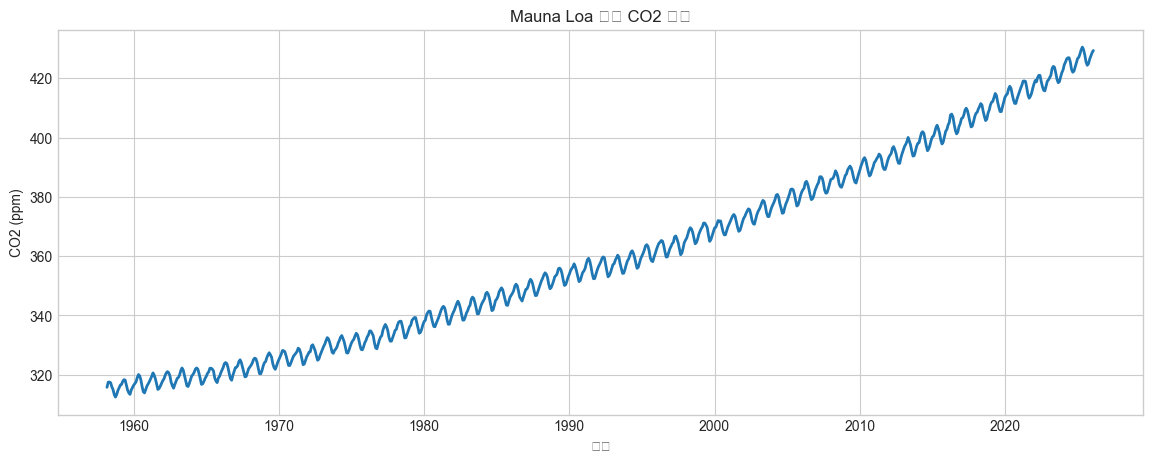

In [ ]:
# 전체 시계열을 시각화하여 추세와 계절성을 확인합니다.
plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts.values, color="tab:blue", linewidth=2)
plt.title("Mauna Loa 월별 CO2 농도")
plt.xlabel("날짜")
plt.ylabel("CO2 (ppm)")
plt.show()


## 학습/테스트 분리와 예측

이번 예제에서는 **마지막 24개월**을 테스트 구간으로 두고,
**Holt-Winters 모델**과 **계절형 naive baseline**을 비교합니다.

In [ ]:
# 마지막 24개월을 테스트 데이터로 사용합니다.
test_size = 24
seasonal_period = 12

train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]

# 계절형 naive baseline은 '작년 같은 달 값'을 그대로 예측합니다.
seasonal_naive_pred = ts.shift(seasonal_period).loc[test.index]

# Holt-Winters 모델은 추세와 계절성을 함께 반영합니다.
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=seasonal_period,
    initialization_method="estimated"
).fit(optimized=True)

hw_pred = hw_model.forecast(test_size)

# MAPE 계산 함수를 직접 정의합니다.
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

result = pd.DataFrame({
    "Actual": test,
    "SeasonalNaive": seasonal_naive_pred,
    "HoltWinters": hw_pred
})

metrics = pd.DataFrame({
    "Model": ["Seasonal Naive", "Holt-Winters"],
    "MAE": [
        mean_absolute_error(test, seasonal_naive_pred),
        mean_absolute_error(test, hw_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(test, seasonal_naive_pred)),
        np.sqrt(mean_squared_error(test, hw_pred))
    ],
    "MAPE(%)": [
        mape(test, seasonal_naive_pred),
        mape(test, hw_pred)
    ]
})

display(result.head())
display(metrics.round(3))


,Actual,SeasonalNaive,HoltWinters
2024-03-01,425.38,420.99,424.833464
2024-04-01,426.51,423.31,426.452493
2024-05-01,426.90,424.00,427.104866
2024-06-01,426.91,423.68,426.492833
2024-07-01,425.55,421.83,424.548875


,Model,MAE,RMSE,MAPE(%)
0,Seasonal Naive,2.998,3.061,0.703
1,Holt-Winters,0.610,0.660,0.143


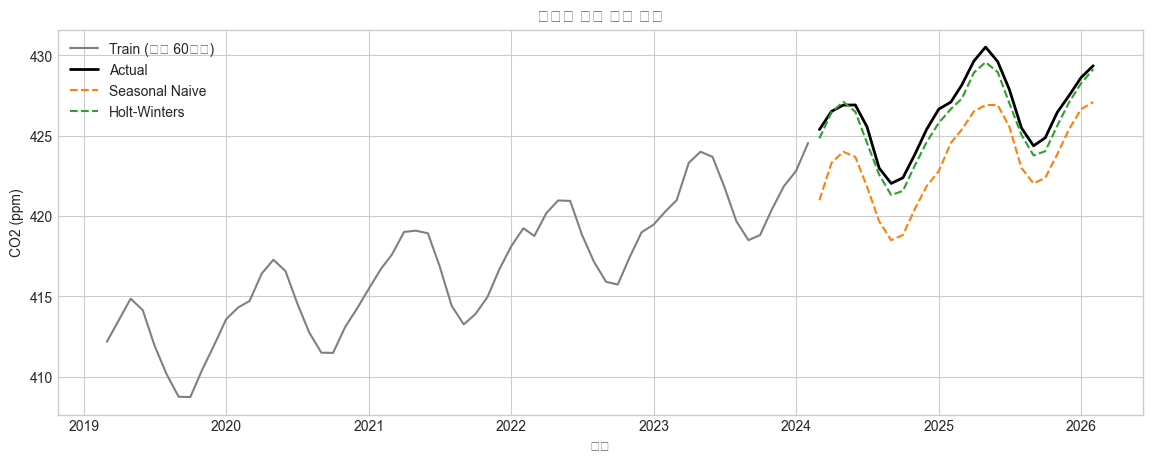

In [ ]:
# 테스트 구간에서 실제값과 예측값을 비교합니다.
plt.figure(figsize=(14, 5))
plt.plot(train.index[-60:], train.iloc[-60:], label="Train (최근 60개월)", color="gray")
plt.plot(test.index, test, label="Actual", color="black", linewidth=2)
plt.plot(test.index, seasonal_naive_pred, label="Seasonal Naive", linestyle="--", color="tab:orange")
plt.plot(test.index, hw_pred, label="Holt-Winters", linestyle="--", color="tab:green")
plt.title("테스트 구간 예측 비교")
plt.xlabel("날짜")
plt.ylabel("CO2 (ppm)")
plt.legend()
plt.show()


## 미래 예측

이제 전체 데이터를 다시 학습한 뒤, **향후 24개월**을 예측합니다.

,forecast
date,
2026-03-01,430.163008
2026-04-01,431.673364
2026-05-01,432.331243
2026-06-01,431.747788
2026-07-01,429.885303
2026-08-01,427.782832
2026-09-01,426.584800
2026-10-01,426.872290
2026-11-01,428.433361


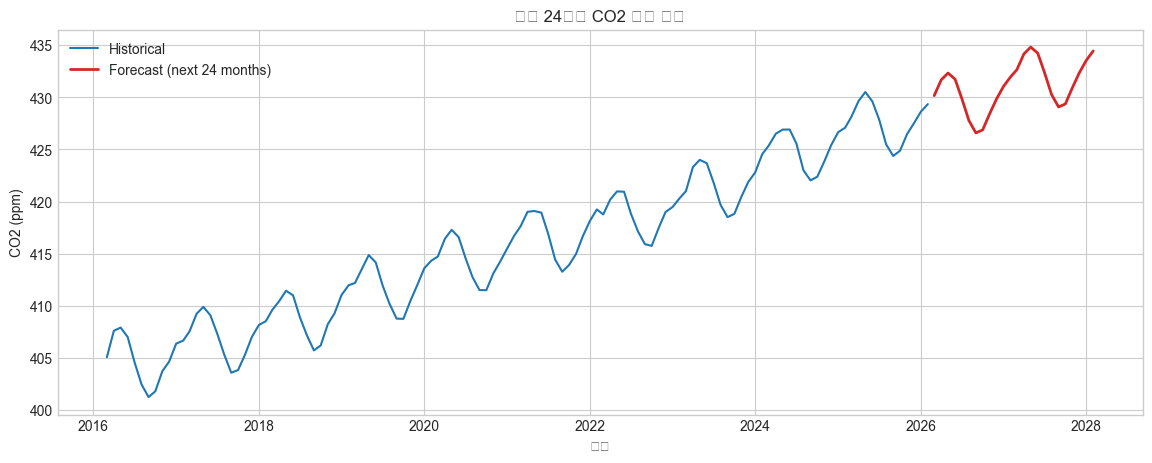

In [ ]:
# 전체 데이터를 사용해 최종 모델을 다시 학습합니다.
final_model = ExponentialSmoothing(
    ts,
    trend="add",
    seasonal="add",
    seasonal_periods=seasonal_period,
    initialization_method="estimated"
).fit(optimized=True)

# 앞으로 24개월을 예측합니다.
future_steps = 24
future_forecast = final_model.forecast(future_steps)
future_df = future_forecast.rename("forecast").to_frame()
future_df.index.name = "date"

display(future_df.head(12))

plt.figure(figsize=(14, 5))
plt.plot(ts.index[-120:], ts.iloc[-120:], label="Historical", color="tab:blue")
plt.plot(future_df.index, future_df["forecast"], label="Forecast (next 24 months)", color="tab:red", linewidth=2)
plt.title("향후 24개월 CO2 농도 예측")
plt.xlabel("날짜")
plt.ylabel("CO2 (ppm)")
plt.legend()
plt.show()


## 결과 해석 예시

- CO2 데이터는 장기 상승 추세와 연간 계절성을 동시에 보입니다.
- 따라서 단순 평균보다 계절성과 추세를 반영하는 모델이 적합합니다.
- 실습 사이트 예제로 올릴 때는 같은 구조를 유지한 채 다른 공공 시계열 URL로 쉽게 바꿔 쓸 수 있습니다.

확장 아이디어:
- SARIMA로 모델 변경
- Prophet과 성능 비교
- 외생변수를 넣는 다변량 예측 예제로 확장